# Facial Emotion Detection
### CNN Model using FER-2013 Dataset
**Detects 7 emotions:** Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise

In [1]:
import sys
print(sys.executable)

d:\Study\sem 4\python Ai subject\New folder\EmotiSense_AI_v3_Fixed\face\venv310\Scripts\python.exe


## Step 1 — Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('All libraries imported successfully!')

TensorFlow version: 2.21.0
GPU available: False
All libraries imported successfully!


## Step 2 — Configuration

In [5]:
import os

# Image settings
IMG_SIZE    = 48
BATCH_SIZE  = 64
EPOCHS      = 60
NUM_CLASSES = 7

# Emotion labels
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Local dataset paths
TRAIN_DIR = r'D:\Study\sem 4\python Ai subject\New folder\EmotiSense_AI_v3_Fixed\dataset\archive (2)\train'
TEST_DIR  = r'D:\Study\sem 4\python Ai subject\New folder\EmotiSense_AI_v3_Fixed\dataset\archive (2)\test'

# Model save path
MODEL_PATH = 'emotion_model.keras'

print('Configuration set!')
print(f'Train path exists: {os.path.exists(TRAIN_DIR)}')
print(f'Test path exists : {os.path.exists(TEST_DIR)}')
print(f'Train folders    : {os.listdir(TRAIN_DIR)}')

Configuration set!
Train path exists: True
Test path exists : True
Train folders    : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Step 3 — Data Loading & Augmentation

In [6]:
# Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Only rescaling for test
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nTraining samples : {train_generator.n}')
print(f'Testing samples  : {test_generator.n}')
print(f'Class indices    : {train_generator.class_indices}')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

Training samples : 28709
Testing samples  : 7178
Class indices    : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


## Step 4 — Visualize Sample Images

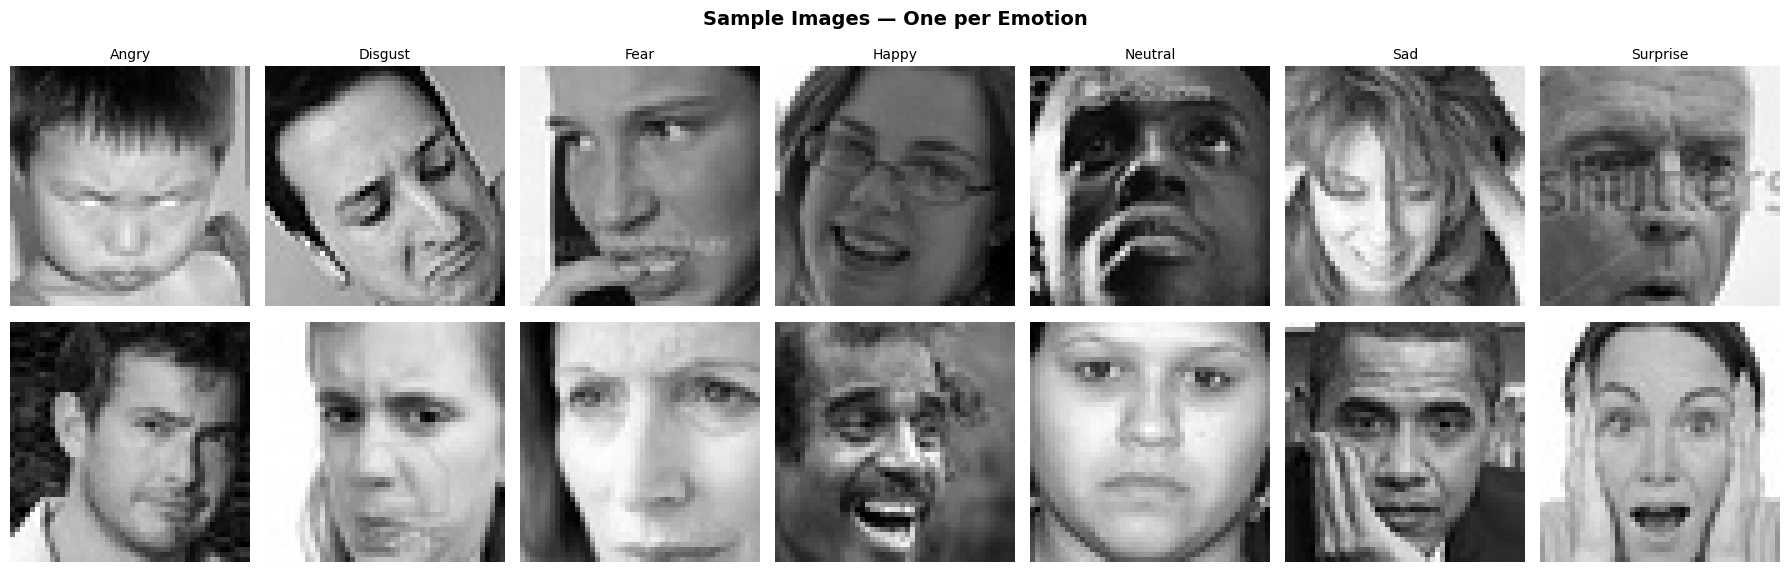

In [7]:
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle('Sample Images — One per Emotion', fontsize=14, fontweight='bold')

for idx, emotion in enumerate(EMOTIONS):
    emotion_path = os.path.join(TRAIN_DIR, emotion)
    if os.path.exists(emotion_path):
        images = os.listdir(emotion_path)
        for row in range(2):
            img = cv2.imread(os.path.join(emotion_path, images[row]), cv2.IMREAD_GRAYSCALE)
            axes[row][idx].imshow(img, cmap='gray')
            if row == 0:
                axes[row][idx].set_title(emotion.capitalize(), fontsize=10)
            axes[row][idx].axis('off')

plt.tight_layout()
plt.show()

## Step 5 — Dataset Distribution

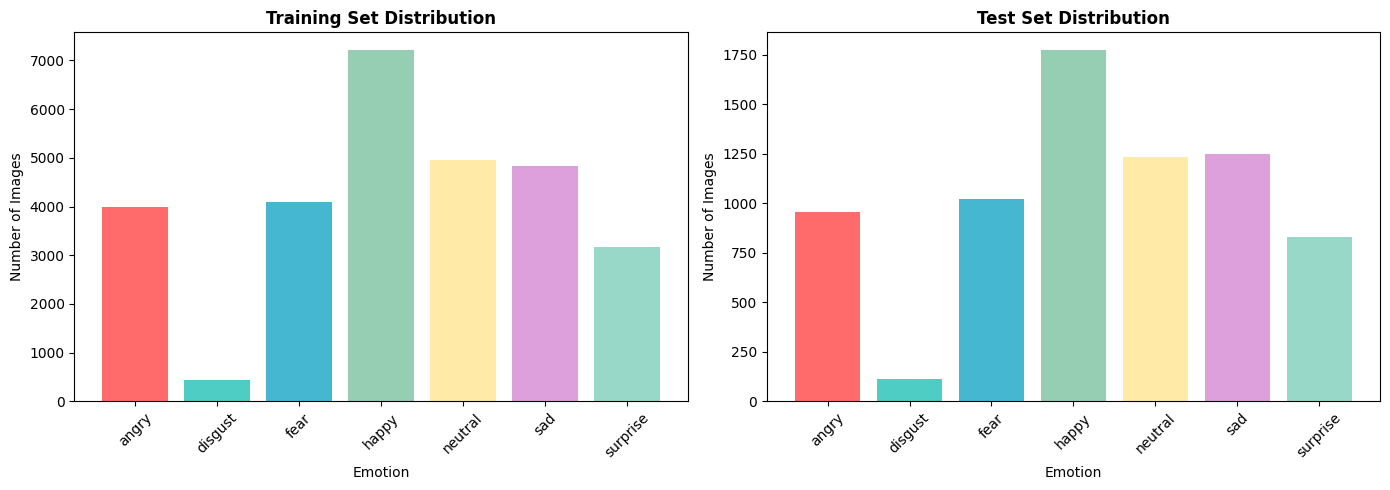

Train: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test : {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


In [8]:
train_counts = {e: len(os.listdir(os.path.join(TRAIN_DIR, e))) for e in EMOTIONS}
test_counts  = {e: len(os.listdir(os.path.join(TEST_DIR,  e))) for e in EMOTIONS}

colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set Distribution', fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Test Set Distribution', fontweight='bold')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Train:', train_counts)
print('Test :', test_counts)

## Step 6 — Build CNN Model

In [9]:
def build_emotion_model(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([

        # Block 1
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(momentum=0.99, epsilon=0.001),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(momentum=0.99, epsilon=0.001),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(momentum=0.99, epsilon=0.001),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 4
        Conv2D(256, (3, 3), activation='relu'),
        BatchNormalization(momentum=0.99, epsilon=0.001),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Classifier Head
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(momentum=0.99, epsilon=0.001),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model


model = build_emotion_model()

model.compile(
    optimizer=RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-7),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,375 (1.75 MB)

 Trainable params: 456,903 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Step 7 — Callbacks

In [10]:
callbacks = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]
print('Callbacks ready!')

Callbacks ready!


## Step 8 — Train the Model

In [16]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1
)
print('\nTraining Complete!')

Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5535 - loss: 1.1783
Epoch 1: val_accuracy improved from None to 0.53121, saving model to emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 702s 2s/step - accuracy: 0.5542 - loss: 1.1762 - val_accuracy: 0.5312 - val_loss: 1.2439 - learning_rate: 0.0010
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.5542 - loss: 1.1718
Epoch 2: val_accuracy improved from 0.53121 to 0.58373, saving model to emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.5548 - loss: 1.1671 - val_accuracy: 0.5837 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5562 - loss: 1.1607
Epoch 3: val_accuracy improved from 0.58373 to 0.60894, saving model to emotion_model.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - accuracy: 0.5593 - loss: 1.1631 - val_accuracy: 0.6089 - val_loss: 1.0412 - learning_rate: 0.0010
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 

## Step 9 — Training History Plots

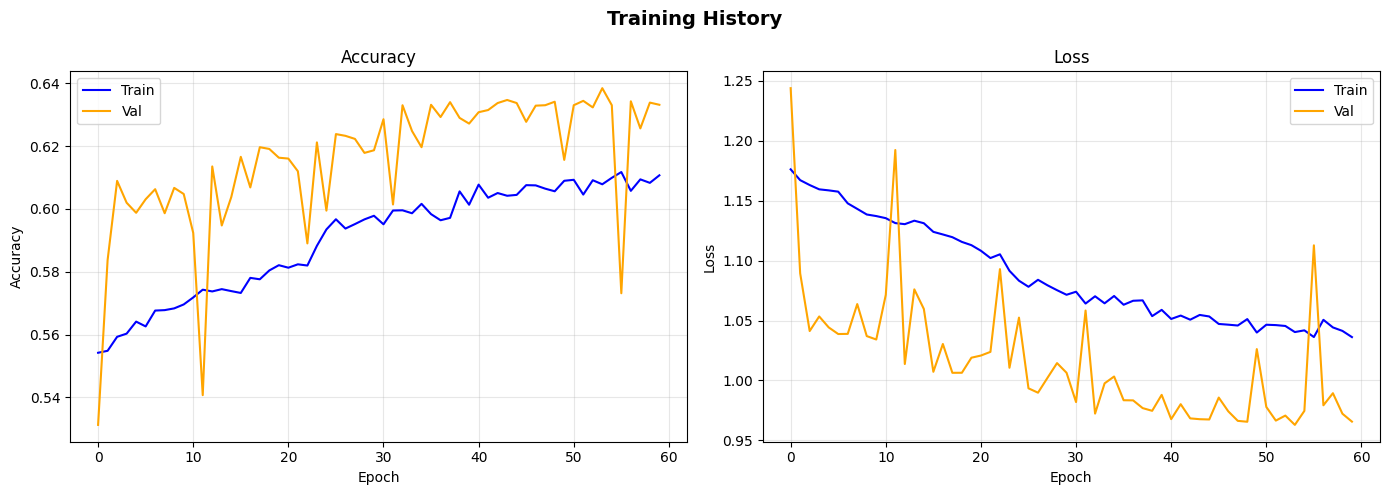

Best Val Accuracy: 0.6385


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='blue')
axes[1].plot(history.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best Val Accuracy: {max(history.history["val_accuracy"]):.4f}')

## Step 10 — Evaluate Model

In [19]:
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.6385 - loss: 0.9630

Test Loss     : 0.9630
Test Accuracy : 0.6385 (63.85%)


## Step 11 — Confusion Matrix

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


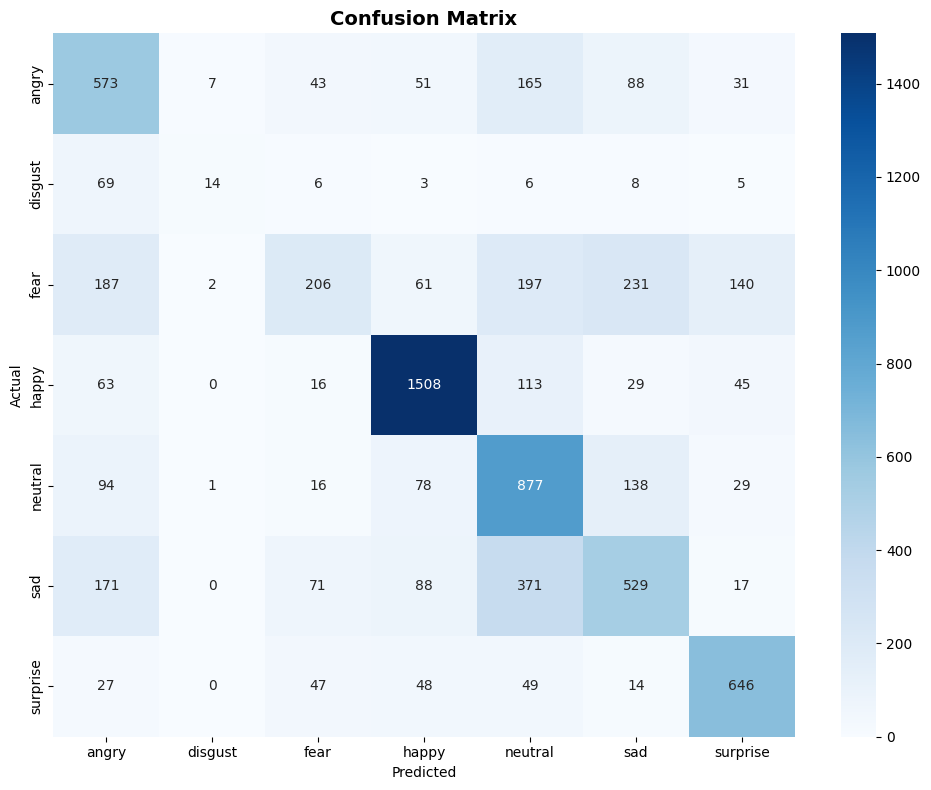

In [15]:
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=EMOTIONS, yticklabels=EMOTIONS
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 12 — Classification Report

In [20]:
print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=EMOTIONS))

Classification Report
              precision    recall  f1-score   support

       angry       0.48      0.60      0.54       958
     disgust       0.58      0.13      0.21       111
        fear       0.51      0.20      0.29      1024
       happy       0.82      0.85      0.84      1774
     neutral       0.49      0.71      0.58      1233
         sad       0.51      0.42      0.46      1247
    surprise       0.71      0.78      0.74       831

    accuracy                           0.61      7178
   macro avg       0.59      0.53      0.52      7178
weighted avg       0.60      0.61      0.59      7178



## Step 13 — Predict Single Image

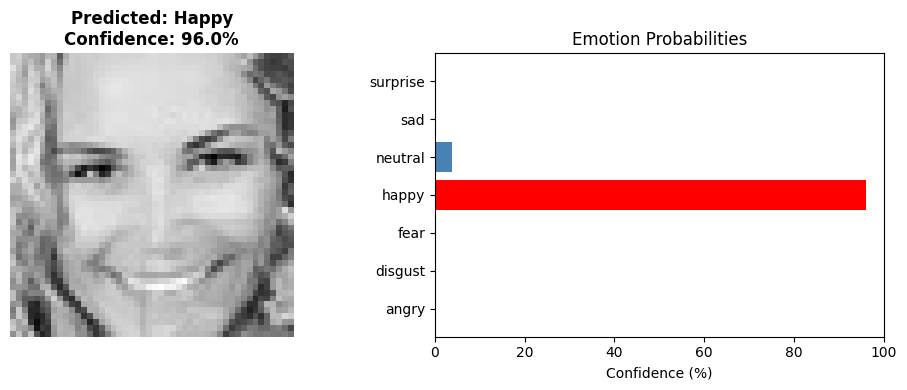

Predicted: happy (96.0%)


In [21]:
def predict_emotion(image_path, model):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)

    predictions = model.predict(img, verbose=0)
    pred_idx    = np.argmax(predictions[0])
    confidence  = predictions[0][pred_idx] * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img[0, :, :, 0], cmap='gray')
    axes[0].set_title(
        f'Predicted: {EMOTIONS[pred_idx].capitalize()}\nConfidence: {confidence:.1f}%',
        fontweight='bold'
    )
    axes[0].axis('off')

    bar_colors = ['red' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
    axes[1].barh(EMOTIONS, predictions[0] * 100, color=bar_colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Emotion Probabilities')
    axes[1].set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

    return EMOTIONS[pred_idx], confidence

# Test on a sample image from test set
sample_img = os.path.join(TEST_DIR, EMOTIONS[3], os.listdir(os.path.join(TEST_DIR, EMOTIONS[3]))[0])
emotion, conf = predict_emotion(sample_img, best_model)
print(f'Predicted: {emotion} ({conf:.1f}%)')

# Save model